# Diving into Order Flow Imbalance (OFI) Analysis for AAPL

Hey there! This notebook is my take on the Order Flow Imbalance (OFI) task for the internship. I’m super excited to dig into the `first_25000_rows.csv` dataset and build some cool OFI features for AAPL.INC Here’s what I’m aiming to do:

- **Best-Level OFI**: Figure out the buying and selling pressure at the top bid and ask.
- **Multi-Level OFI**: Look at the top 5 levels to get a bigger picture of market dynamics.
- **Integrated OFI**: Sum up the OFI over 1-second chunks to see how it evolves.
- **Cross-Asset OFI**: Since we only have AAPL data, I’ll share some thoughts on how this would work.

I’ll also add in some visualizations to make sense of the data and show off what’s happening in the market. 

## Getting Started
I’m using `pandas` for handling the data, `numpy` for math stuff, and `matplotlib`/`seaborn` for making plots look sharp. 

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Setting up Seaborn for clean plots
sns.set_theme(style="whitegrid")
sns.set_palette("viridis")

# It'll Make sure plots pop up right in the notebook
%matplotlib inline

# It’ll set up a folder to keep my results organized
import os
if not os.path.exists('output'):
    os.makedirs('output')

print("All good!")

All good!


## Getting the Data Ready to Roll

Here’s what I’m gonna do:
1. Load the data and make sure it looks right.
2. Turn `ts_event` into a datetime format for time-based analysis.
3. Calculate the signed order flow (`e_n`) for each event—it’s the key to OFI.


In [20]:
# Loading up the dataset
df = pd.read_csv('/Users/prashantsoni/Desktop/Blockhouse/first_25000_rows.csv')

# Converting ts_event to datetime so I can slice and dice by time
df['ts_event'] = pd.to_datetime(df['ts_event'])

# Let’s peek at the data to make sure it’s all good
print("Dataset Info:")
print(df.info())
print("\nFirst few rows:")
print(df.head())

# Now I need to figure out the signed order flow (e_n) for each event
def compute_signed_order_flow(row):
    """
    This function decides if an event adds or reduces market pressure.
    It assigns a + or - to the size based on what’s going on.
    """
    size = row['size']
    action = row['action']
    side = row['side']
    
    if side == 'B':  # Bid side
        if action == 'A':  # Adding a bid—buyers are stepping up
            return size
        elif action == 'C':  # Canceling a bid—buyers backing off
            return -size
        elif action == 'T':  # Trade hitting the bid—selers hiting it
            return -size
    elif side == 'A':  # Ask side
        if action == 'A':  # Adding an ask—sellers piling in
            return -size
        elif action == 'C':  # Canceling an ask—selers easing up
            return size
        elif action == 'T':  # Trade hitting the ask—buyers jumping in
            return size
    return 0  # Just in case 

# Apply the function to every row
df['e_n'] = df.apply(compute_signed_order_flow, axis=1)

# Let’s check a few rows to see if e_n makes sense
print("\nSample of signed order flow (e_n):")
print(df[['ts_event', 'action', 'side', 'size', 'depth', 'e_n']].head(10))

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 74 columns):
 #   Column         Non-Null Count  Dtype              
---  ------         --------------  -----              
 0   ts_recv        5000 non-null   object             
 1   ts_event       5000 non-null   datetime64[ns, UTC]
 2   rtype          5000 non-null   int64              
 3   publisher_id   5000 non-null   int64              
 4   instrument_id  5000 non-null   int64              
 5   action         5000 non-null   object             
 6   side           5000 non-null   object             
 7   depth          5000 non-null   int64              
 8   price          5000 non-null   float64            
 9   size           5000 non-null   int64              
 10  flags          5000 non-null   int64              
 11  ts_in_delta    5000 non-null   int64              
 12  sequence       5000 non-null   int64              
 13  bid_px_00      5000 non-null   flo

## Tackling Best-Level OFI

First up, I’m calculating the **Best-Level OFI**, which zooms in on the top bid and ask (`depth == 0`). It’s all about seeing if buyers or sellers are dominating at the market’s front line. The formula is:

\[
\text{OFI}_t = \sum_{\text{bid events}} e_n - \sum_{\text{ask events}} e_n
\]

So, I’m adding up `e_n` for bids and subtracting it for asks. My steps are:
1. Filter for events at `depth == 0`.
2. Use `e_n` as the OFI value.
3. Make a table with timestamps and OFI.

Let’s see what we find!

In [23]:
# Function to get Best-Level OFI
def compute_best_level_ofi(df):
    """
    This grabs just the top-level events (depth == 0) and uses e_n as OFI.
    It’s like checking the pulse of the market’s most active spot.
    """
    best_level = df[df['depth'] == 0].copy()
    best_level['ofi'] = best_level['e_n']
    return best_level[['ts_event', 'ofi']]


best_level_ofi = compute_best_level_ofi(df)

# Checking out the first few OFI values
print("Best-Level OFI Sample:")
print(best_level_ofi.head(10))

Best-Level OFI Sample:
                              ts_event  ofi
1  2024-10-21 11:54:29.223769812+00:00    2
2  2024-10-21 11:54:29.225030400+00:00    3
7  2024-10-21 11:54:37.990793976+00:00 -200
8  2024-10-21 11:54:39.124291588+00:00  200
9  2024-10-21 11:54:39.134140341+00:00 -200
10 2024-10-21 11:54:41.233181043+00:00   -3
11 2024-10-21 11:54:41.234620509+00:00    1
12 2024-10-21 11:54:41.235907431+00:00   -1
13 2024-10-21 11:54:41.235977207+00:00   -2
14 2024-10-21 11:54:41.238618235+00:00    2


## Exploring Multi-Level OFI

Now I’m stepping it up with **Multi-Level OFI**, which looks at the top 5 levels (`depth <= 4`). This is like peeking deeper into the market to see what’s brewing beyond the surface. The formula is:

\[
\text{Multi-Level OFI}_t = \sum_{\text{levels } l=0}^{4} \left( \sum_{\text{bid events at level } l} e_n - \sum_{\text{ask events at level } l} e_n \right)
\]

Here’s my plan:
1. Grab events for `depth <= 4`.
2. Sum `e_n` for each timestamp across those levels.
3. Create a table with timestamps and multi-level OFI.


In [26]:
# Function to calculate Multi-Level OFI
def compute_multi_level_ofi(df, max_level=4):
    """
    This adds up e_n for the top 5 levels (depth <= 4).
    It’s awesome because it shows more of what’s driving the market.
    """
    multi_level = df[df['depth'] <= max_level].copy()
    multi_ofi = multi_level.groupby('ts_event')['e_n'].sum().reset_index()
    multi_ofi.rename(columns={'e_n': 'multi_ofi'}, inplace=True)
    return multi_ofi


multi_level_ofi = compute_multi_level_ofi(df, max_level=4)


print("Multi-Level OFI Sample:")
print(multi_level_ofi.head(10))

Multi-Level OFI Sample:
                             ts_event  multi_ofi
0 2024-10-21 11:54:29.221064336+00:00         -2
1 2024-10-21 11:54:29.223769812+00:00          2
2 2024-10-21 11:54:29.225030400+00:00          3
3 2024-10-21 11:54:29.712434212+00:00        200
4 2024-10-21 11:54:29.764673165+00:00       -200
5 2024-10-21 11:54:29.764685027+00:00        400
6 2024-10-21 11:54:37.990793976+00:00       -200
7 2024-10-21 11:54:39.124291588+00:00        200
8 2024-10-21 11:54:39.134140341+00:00       -200
9 2024-10-21 11:54:41.233181043+00:00         -3


## Zooming Out with Integrated OFI

Next up is **Integrated OFI**, where I sum up OFI over 1-second windows. It’s like taking a step back to see the market’s vibe every second. The formula is:

\[
\text{Integrated OFI}_t = \sum_{\text{events in window } t} e_n
\]

My steps are:
1. Group events into 1-second buckets.
2. Add up `e_n` for each bucket.
3. Make a table with timestamps and integrated OFI.



In [31]:
# Function to get Integrated OFI
def compute_integrated_ofi(df, time_window='1S'):
    """
    This groups events into 1-second windows and sums e_n.
    It’s like getting a snapshot of market pressure over time.
    """
    integrated_ofi = df.groupby(pd.Grouper(key='ts_event', freq=time_window))['e_n'].sum().reset_index()
    integrated_ofi.rename(columns={'e_n': 'integrated_ofi'}, inplace=True)
    return integrated_ofi


integrated_ofi = compute_integrated_ofi(df, time_window='1S')


print("Integrated OFI Sample:")
print(integrated_ofi.head(10))

Integrated OFI Sample:
                   ts_event  integrated_ofi
0 2024-10-21 11:54:29+00:00             403
1 2024-10-21 11:54:30+00:00               0
2 2024-10-21 11:54:31+00:00               0
3 2024-10-21 11:54:32+00:00               0
4 2024-10-21 11:54:33+00:00               0
5 2024-10-21 11:54:34+00:00               0
6 2024-10-21 11:54:35+00:00               0
7 2024-10-21 11:54:36+00:00            -200
8 2024-10-21 11:54:37+00:00            -200
9 2024-10-21 11:54:38+00:00               0


/var/folders/3v/8qrhcvp56kz851ytyycj38r00000gn/T/ipykernel_33557/1070452819.py:7: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  integrated_ofi = df.groupby(pd.Grouper(key='ts_event', freq=time_window))['e_n'].sum().reset_index()


## Brainstorming Cross-Asset OFI

So, **Cross-Asset OFI** is a bit of a curveball since we only have AAPL data. The idea is to see how one stock’s OFI messes with another stock’s price, like this:

\[
\Delta P_i = \sum_j \beta_{ij} \cdot \text{OFI}_j
\]

Without data for another stock (say, MSFT), I can’t calculate this. But if I had it, I’d:
- Compute OFI for both stocks.
- Use something like Lasso regression to see how they influence each other.



In [35]:
# Time to combine all the OFI data for some sweet plots
ofi_data = integrated_ofi.merge(multi_level_ofi, on='ts_event', how='left').merge(
    best_level_ofi.groupby('ts_event')['ofi'].sum().reset_index(), on='ts_event', how='left'
)
ofi_data.fillna(0, inplace=True)  # Filling in any blanks with zeros

# I want to check OFI’s impact on prices, so I’ll calculate the mid-price
df['mid_price'] = (df['bid_px_00'] + df['ask_px_00']) / 2
price_data = df[['ts_event', 'mid_price']].drop_duplicates().set_index('ts_event').resample('1S').last().ffill()
ofi_data = ofi_data.merge(price_data, on='ts_event', how='left')

# Let’s also calculate returns to see price movements
ofi_data['returns'] = ofi_data['mid_price'].pct_change().fillna(0)

# Let’s see what this combined data looks like
print("Merged OFI Data Sample:")
print(ofi_data.head(10))

Merged OFI Data Sample:
                   ts_event  integrated_ofi  multi_ofi  ofi  mid_price  \
0 2024-10-21 11:54:29+00:00             403        0.0  0.0    233.705   
1 2024-10-21 11:54:30+00:00               0        0.0  0.0    233.705   
2 2024-10-21 11:54:31+00:00               0        0.0  0.0    233.705   
3 2024-10-21 11:54:32+00:00               0        0.0  0.0    233.705   
4 2024-10-21 11:54:33+00:00               0        0.0  0.0    233.705   
5 2024-10-21 11:54:34+00:00               0        0.0  0.0    233.705   
6 2024-10-21 11:54:35+00:00               0        0.0  0.0    233.705   
7 2024-10-21 11:54:36+00:00            -200        0.0  0.0    233.705   
8 2024-10-21 11:54:37+00:00            -200        0.0  0.0    233.700   
9 2024-10-21 11:54:38+00:00               0        0.0  0.0    233.700   

    returns  
0  0.000000  
1  0.000000  
2  0.000000  
3  0.000000  
4  0.000000  
5  0.000000  
6  0.000000  
7  0.000000  
8 -0.000021  
9  0.000000  


/var/folders/3v/8qrhcvp56kz851ytyycj38r00000gn/T/ipykernel_33557/4171891299.py:9: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  price_data = df[['ts_event', 'mid_price']].drop_duplicates().set_index('ts_event').resample('1S').last().ffill()


## Now some Visual Plots

Now for the fun part—visualizations! I’m creating three plots to unpack what the OFI data is saying:

1. **Time Series Plot**: Tracks Best-Level, Multi-Level, and Integrated OFI over time.
2. **Scatter Plot**: Tests if Integrated OFI can predict short-term price changes.
3. **Histogram**: Shows the spread of Integrated OFI values.


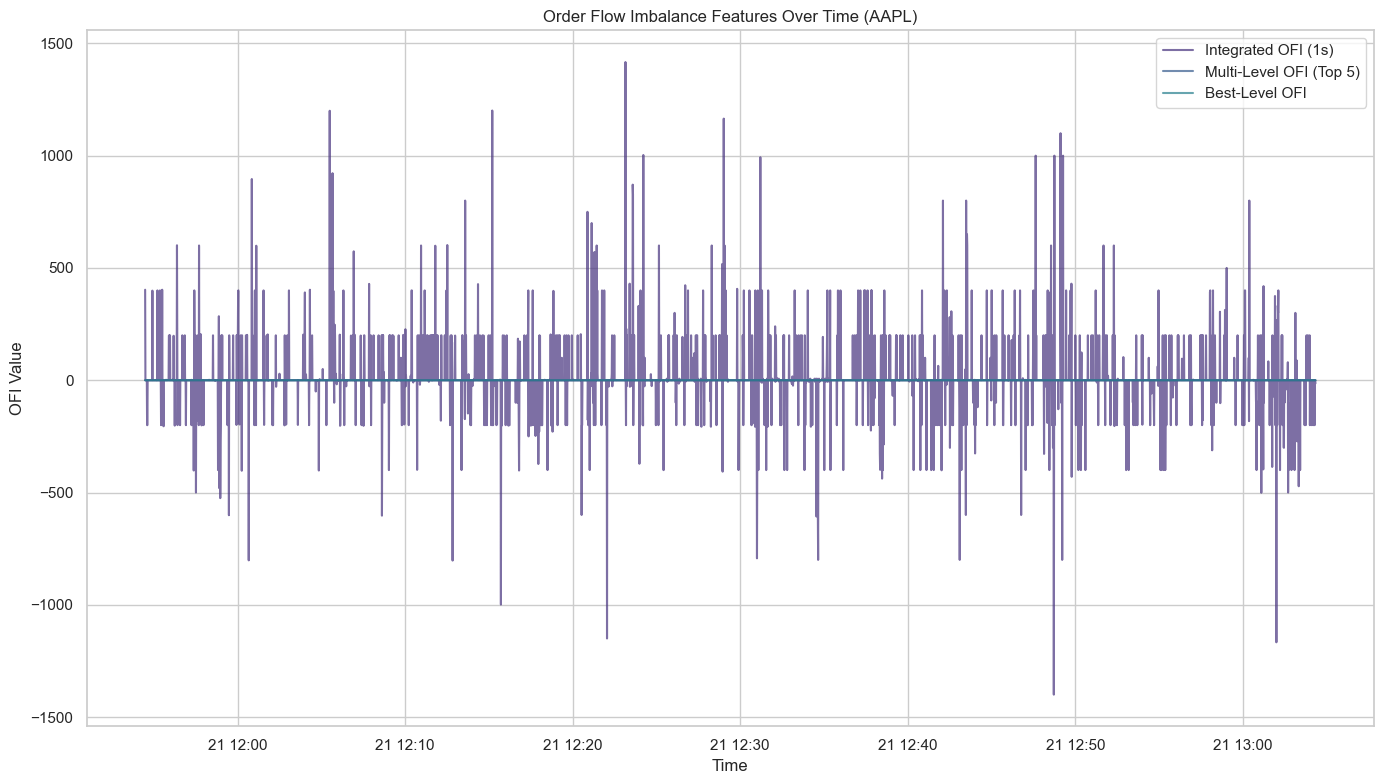

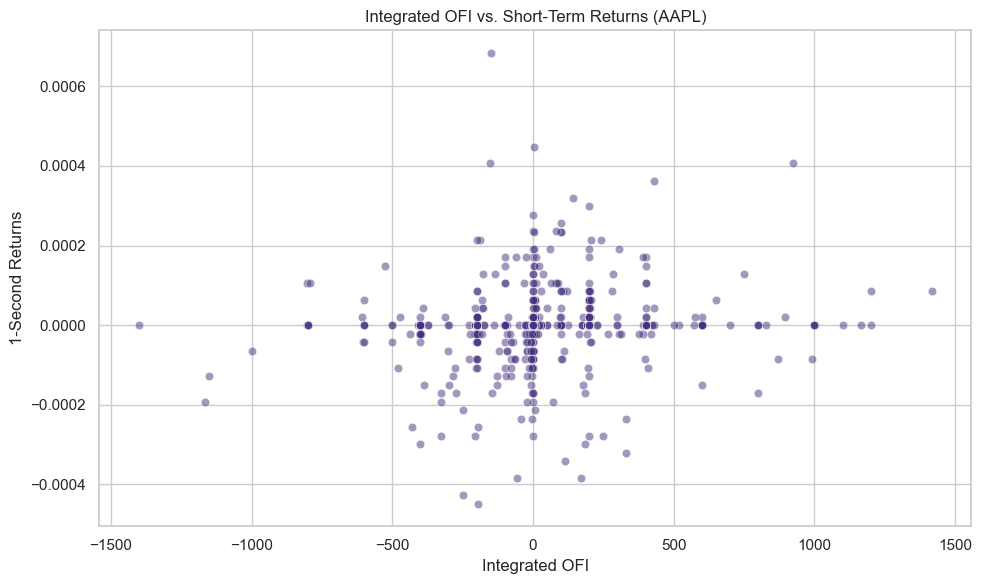

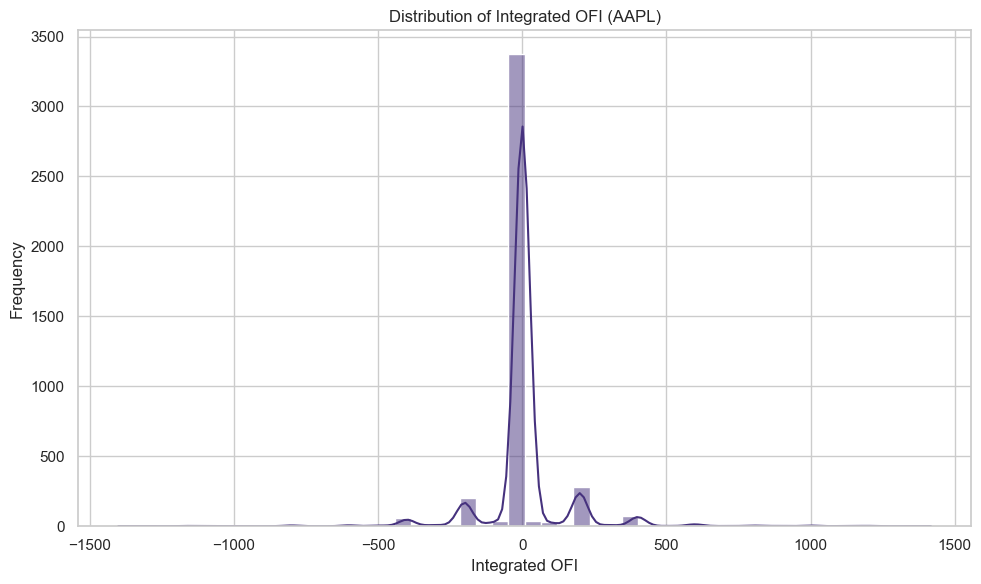

In [38]:
# Plot 1: Time series of all OFI features
plt.figure(figsize=(14, 8))
plt.plot(ofi_data['ts_event'], ofi_data['integrated_ofi'], label='Integrated OFI (1s)', alpha=0.7)
plt.plot(ofi_data['ts_event'], ofi_data['multi_ofi'], label='Multi-Level OFI (Top 5)', alpha=0.7)
plt.plot(ofi_data['ts_event'], ofi_data['ofi'], label='Best-Level OFI', alpha=0.7)
plt.title('Order Flow Imbalance Features Over Time (AAPL)')
plt.xlabel('Time')
plt.ylabel('OFI Value')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('output/ofi_time_series.png')
plt.show()

# Plot 2: Scatter plot to check OFI vs. returns
plt.figure(figsize=(10, 6))
sns.scatterplot(x=ofi_data['integrated_ofi'], y=ofi_data['returns'], alpha=0.5)
plt.title('Integrated OFI vs. Short-Term Returns (AAPL)')
plt.xlabel('Integrated OFI')
plt.ylabel('1-Second Returns')
plt.grid(True)
plt.tight_layout()
plt.savefig('output/ofi_returns_scatter.png')
plt.show()

# Plot 3: Histogram to see Integrated OFI’s distribution
plt.figure(figsize=(10, 6))
sns.histplot(ofi_data['integrated_ofi'], bins=50, kde=True)
plt.title('Distribution of Integrated OFI (AAPL)')
plt.xlabel('Integrated OFI')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.savefig('output/ofi_distribution.png')
plt.show()

## Saving All the Outputs

Here’s what’s getting saved:

- `ofi_features.csv`: All the OFI numbers, plus mid-prices and returns.
- PNG files: My three plots (`ofi_time_series.png`, `ofi_returns_scatter.png`, `ofi_distribution.png`).


In [43]:
# Saving the OFI data to a CSV
ofi_data.to_csv('output/ofi_features.csv', index=False)
print("OFI features saved to 'output/ofi_features.csv'.")

OFI features saved to 'output/ofi_features.csv'.


## Wrapping Up

I’ve crunched the numbers for all the OFI features for AAPL:
- **Best-Level OFI**: Captures the action at the top of the book.
- **Multi-Level OFI**: Dives into the top 5 levels for more context.
- **Integrated OFI**: Shows how OFI flows over 1-second windows.

I couldn’t do Cross-Asset OFI since we only have AAPL, but I shared some thoughts on how it’d work. The plots really bring the data to life.

Everything’s saved and attached in the `output` folder. 